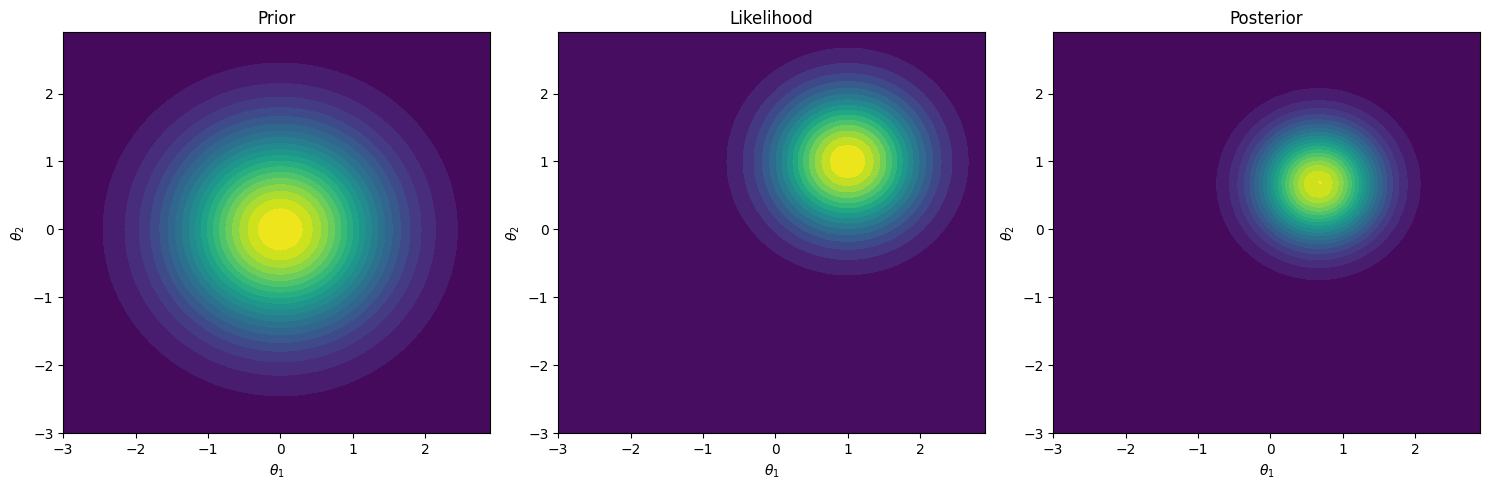

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define the prior
mu_0 = np.array([0, 0])  # Prior mean
Sigma_0 = np.array([[1, 0], [0, 1]])  # Prior covariance matrix

# Define the likelihood (data distribution)
y = np.array([1, 1])  # Observed data
Sigma = np.array([[0.5, 0], [0, 0.5]])  # Covariance matrix of the data

# Compute the posterior
Sigma_p = np.linalg.inv(np.linalg.inv(Sigma_0) + np.linalg.inv(Sigma))
mu_p = Sigma_p @ (np.linalg.inv(Sigma_0) @ mu_0 + np.linalg.inv(Sigma) @ y)

# Create grid for visualization
x1, x2 = np.mgrid[-3:3:0.1, -3:3:0.1]
pos = np.dstack((x1, x2))

# Evaluate prior, likelihood, and posterior on the grid
prior = multivariate_normal(mu_0, Sigma_0)
likelihood = multivariate_normal(y, Sigma)
posterior = multivariate_normal(mu_p, Sigma_p)

prior_pdf = prior.pdf(pos)
likelihood_pdf = likelihood.pdf(pos)
posterior_pdf = posterior.pdf(pos)

# Plot prior, likelihood, and posterior
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prior
axes[0].contourf(x1, x2, prior_pdf, levels=20, cmap="viridis")
axes[0].set_title("Prior")
axes[0].set_xlabel(r"$\theta_1$")
axes[0].set_ylabel(r"$\theta_2$")

# Likelihood
axes[1].contourf(x1, x2, likelihood_pdf, levels=20, cmap="viridis")
axes[1].set_title("Likelihood")
axes[1].set_xlabel(r"$\theta_1$")
axes[1].set_ylabel(r"$\theta_2$")

# Posterior
axes[2].contourf(x1, x2, posterior_pdf, levels=20, cmap="viridis")
axes[2].set_title("Posterior")
axes[2].set_xlabel(r"$\theta_1$")
axes[2].set_ylabel(r"$\theta_2$")

plt.tight_layout()
plt.show()

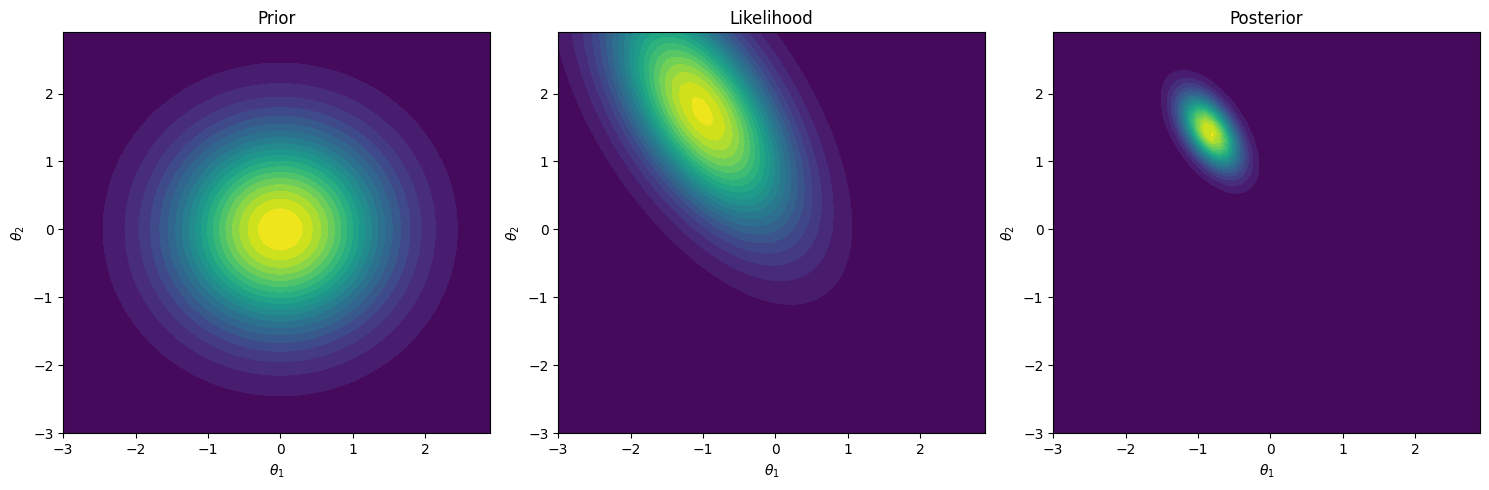

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define the prior
mu_0 = np.array([0, 0])  # Prior mean
Sigma_0 = np.array([[1, 0], [0, 1]])  # Prior covariance matrix

# Define the likelihood (data distribution) with more observed data
y = np.array([[-1, 2], [-1.2, 2.1], [-0.8, 1.9], [-1, 2.2], [-1.1, 1.8], [0, 2], [-0.2, -1], [-2.8, 2.9]])  # More observed data
Sigma = np.array([[0.5, 0], [0, 0.5]])  # Covariance matrix of the data
Sigma = np.cov(y, rowvar=False)
# Compute the posterior
Sigma_inv = np.linalg.inv(Sigma)
Sigma_p = np.linalg.inv(np.linalg.inv(Sigma_0) + len(y) * Sigma_inv)
mu_p = Sigma_p @ (np.linalg.inv(Sigma_0) @ mu_0 + Sigma_inv @ np.sum(y, axis=0))

# Create grid for visualization
x1, x2 = np.mgrid[-3:3:0.1, -3:3:0.1]
pos = np.dstack((x1, x2))

# Evaluate prior, likelihood, and posterior on the grid
prior = multivariate_normal(mu_0, Sigma_0)
likelihood = multivariate_normal(np.mean(y, axis=0), Sigma)
posterior = multivariate_normal(mu_p, Sigma_p)

prior_pdf = prior.pdf(pos)
likelihood_pdf = likelihood.pdf(pos)
posterior_pdf = posterior.pdf(pos)

# Plot prior, likelihood, and posterior
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prior
axes[0].contourf(x1, x2, prior_pdf, levels=20, cmap="viridis")
axes[0].set_title("Prior")
axes[0].set_xlabel(r"$\theta_1$")
axes[0].set_ylabel(r"$\theta_2$")

# Likelihood
axes[1].contourf(x1, x2, likelihood_pdf, levels=20, cmap="viridis")
axes[1].set_title("Likelihood")
axes[1].set_xlabel(r"$\theta_1$")
axes[1].set_ylabel(r"$\theta_2$")

# Posterior
axes[2].contourf(x1, x2, posterior_pdf, levels=20, cmap="viridis")
axes[2].set_title("Posterior")
axes[2].set_xlabel(r"$\theta_1$")
axes[2].set_ylabel(r"$\theta_2$")

plt.tight_layout()
plt.show()


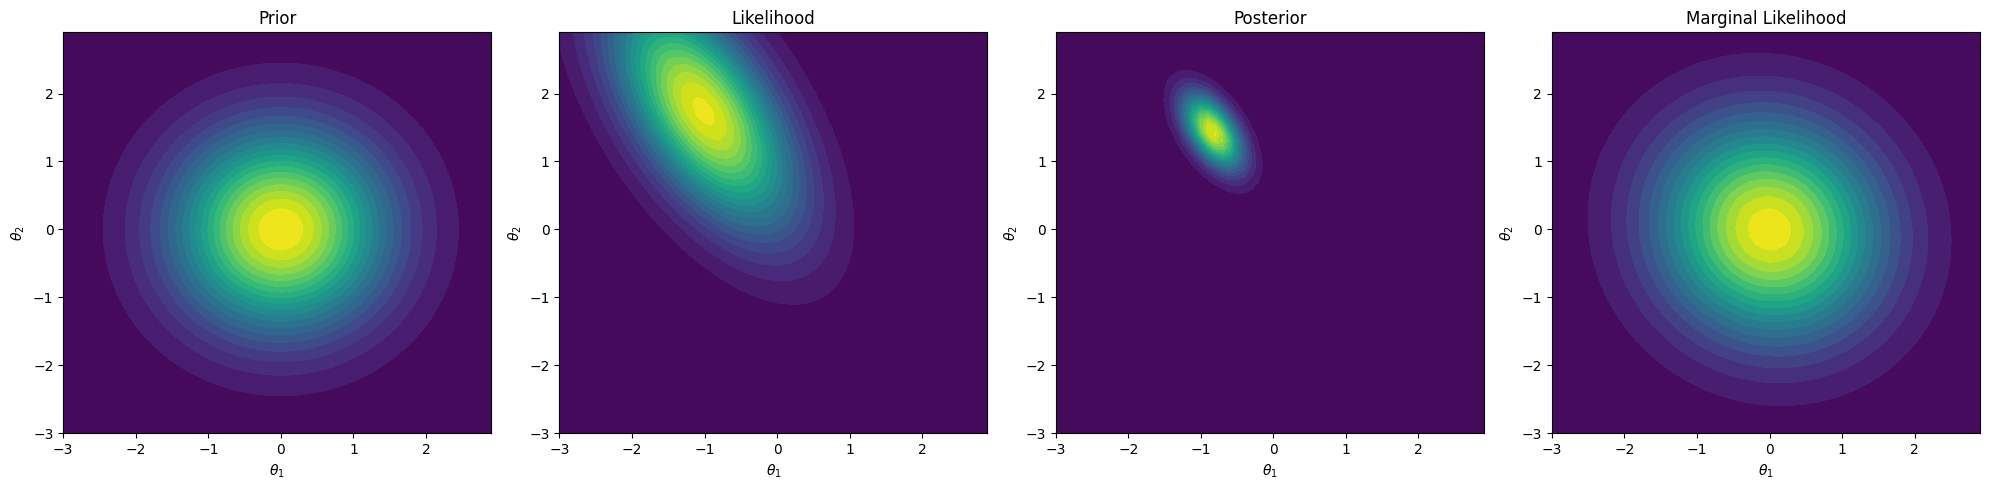

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define the prior
mu_0 = np.array([0, 0])  # Prior mean
Sigma_0 = np.array([[1, 0], [0, 1]])  # Prior covariance matrix

# Define the likelihood (data distribution) with more observed data
y = np.array([[-1, 2], [-1.2, 2.1], [-0.8, 1.9], [-1, 2.2], [-1.1, 1.8], [0, 2], [-0.2, -1], [-2.8, 2.9]])  # More observed data
Sigma = np.cov(y, rowvar=False)

# Compute the posterior
Sigma_inv = np.linalg.inv(Sigma)
Sigma_p = np.linalg.inv(np.linalg.inv(Sigma_0) + len(y) * Sigma_inv)
mu_p = Sigma_p @ (np.linalg.inv(Sigma_0) @ mu_0 + Sigma_inv @ np.sum(y, axis=0))

# Compute the marginal likelihood
marginal_likelihood = multivariate_normal(mu_0, Sigma_0 + Sigma / len(y))
marginal_likelihood_pdf = marginal_likelihood.pdf(pos)

# Create grid for visualization
x1, x2 = np.mgrid[-3:3:0.1, -3:3:0.1]
pos = np.dstack((x1, x2))

# Evaluate prior, likelihood, and posterior on the grid
prior = multivariate_normal(mu_0, Sigma_0)
likelihood = multivariate_normal(np.mean(y, axis=0), Sigma)
posterior = multivariate_normal(mu_p, Sigma_p)

prior_pdf = prior.pdf(pos)
likelihood_pdf = likelihood.pdf(pos)
posterior_pdf = posterior.pdf(pos)

# Plot prior, likelihood, posterior, and marginal likelihood
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Prior
axes[0].contourf(x1, x2, prior_pdf, levels=20, cmap="viridis")
axes[0].set_title("Prior")
axes[0].set_xlabel(r"$\theta_1$")
axes[0].set_ylabel(r"$\theta_2$")

# Likelihood
axes[1].contourf(x1, x2, likelihood_pdf, levels=20, cmap="viridis")
axes[1].set_title("Likelihood")
axes[1].set_xlabel(r"$\theta_1$")
axes[1].set_ylabel(r"$\theta_2$")

# Posterior
axes[2].contourf(x1, x2, posterior_pdf, levels=20, cmap="viridis")
axes[2].set_title("Posterior")
axes[2].set_xlabel(r"$\theta_1$")
axes[2].set_ylabel(r"$\theta_2$")

# Marginal Likelihood
axes[3].contourf(x1, x2, marginal_likelihood_pdf, levels=20, cmap="viridis")
axes[3].set_title("Marginal Likelihood")
axes[3].set_xlabel(r"$\theta_1$")
axes[3].set_ylabel(r"$\theta_2$")

plt.tight_layout()
plt.show()


**calculate marginal likelihood with gaussian prior**


In [3]:
import numpy as np
from scipy.stats import norm

# Define prior parameters
mu_prior = 5.0       # Prior mean
var_prior = 1.0      # Prior variance

# Generate random data
np.random.seed(42)
N = 20               # Number of data points
D = np.random.uniform(0, 10, N)  # Random data between 0 and 10
print(D)

# Define likelihood parameters (assume known noise variance)
sigma_noise = 1.0    # Standard deviation of the noise
var_noise = sigma_noise ** 2

# Compute sufficient statistics of the data
data_mean = np.mean(D)  # Mean of the data
data_var = var_noise / N  # Variance of the sample mean

# Compute marginal likelihood parameters
# For a Gaussian prior and Gaussian likelihood, the marginal likelihood is Gaussian:
# P(D) = N(data_mean | mu_prior, var_prior + data_var)
mu_marginal = mu_prior
var_marginal = var_prior + data_var

# Calculate the marginal likelihood
marginal_likelihood = norm.pdf(data_mean, loc=mu_marginal, scale=np.sqrt(var_marginal))

print(f"Marginal likelihood: {marginal_likelihood:.6f}")



[3.74540119 9.50714306 7.31993942 5.98658484 1.5601864  1.5599452
 0.58083612 8.66176146 6.01115012 7.08072578 0.20584494 9.69909852
 8.32442641 2.12339111 1.81824967 1.8340451  3.04242243 5.24756432
 4.31945019 2.9122914 ]
Marginal likelihood: 0.357533


[6.24724071 9.70428584 8.39196365 7.59195091 4.93611184 4.93596712
 4.34850167 9.19705687 7.60669007 8.24843547 4.12350697 9.81945911
 8.99465584 5.27403466 5.0909498  5.10042706 5.82545346 7.14853859
 6.59167011 5.74737484]
Posterior mean (mu_post): 6.5875
Posterior variance (var_post): 0.0455


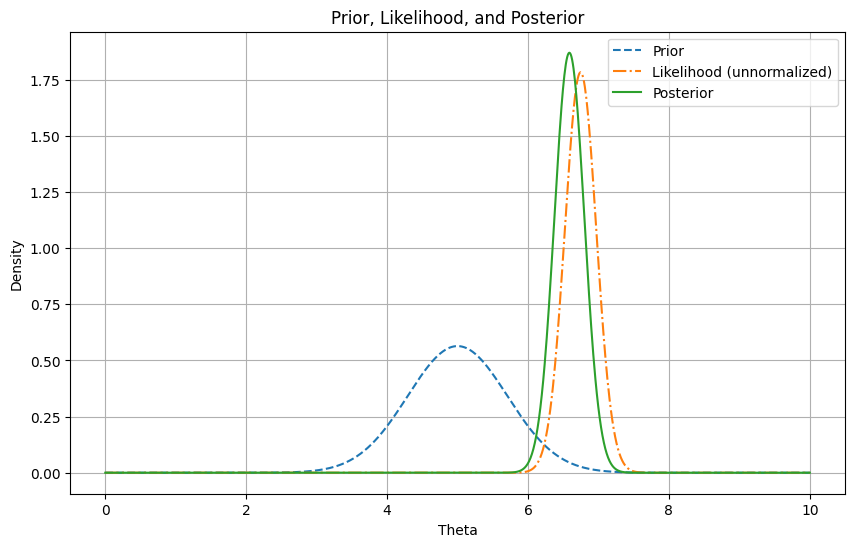

In [17]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Define prior parameters
mu_prior = 5.0       # Prior mean
var_prior = 0.5      # Prior variance

# Generate random data
np.random.seed(42)
N = 20               # Number of data points
D = np.random.uniform(4, 10, N)  # Random data between 0 and 10
print(D)
# Define likelihood parameters (assume known noise variance)
sigma_noise = 1.0    # Standard deviation of the noise
var_noise = sigma_noise ** 2

# Compute sufficient statistics of the data
data_mean = np.mean(D)  # Mean of the data

# Compute posterior parameters
# Posterior mean
mu_post = (mu_prior / var_prior + data_mean * N / var_noise) / (1 / var_prior + N / var_noise)
# Posterior variance
var_post = 1 / (1 / var_prior + N / var_noise)

print(f"Posterior mean (mu_post): {mu_post:.4f}")
print(f"Posterior variance (var_post): {var_post:.4f}")

# Plot the prior, likelihood, and posterior
theta_values = np.linspace(0, 10, 1000)  # Range of theta values for plotting

# Prior distribution
prior = norm.pdf(theta_values, loc=mu_prior, scale=np.sqrt(var_prior))

# Likelihood (unnormalized, centered at data mean)
likelihood = norm.pdf(theta_values, loc=data_mean, scale=np.sqrt(var_noise / N))

# Posterior distribution
posterior = norm.pdf(theta_values, loc=mu_post, scale=np.sqrt(var_post))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(theta_values, prior, label="Prior", linestyle="--")
plt.plot(theta_values, likelihood, label="Likelihood (unnormalized)", linestyle="-.")
plt.plot(theta_values, posterior, label="Posterior", linestyle="-")
plt.title("Prior, Likelihood, and Posterior")
plt.xlabel("Theta")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

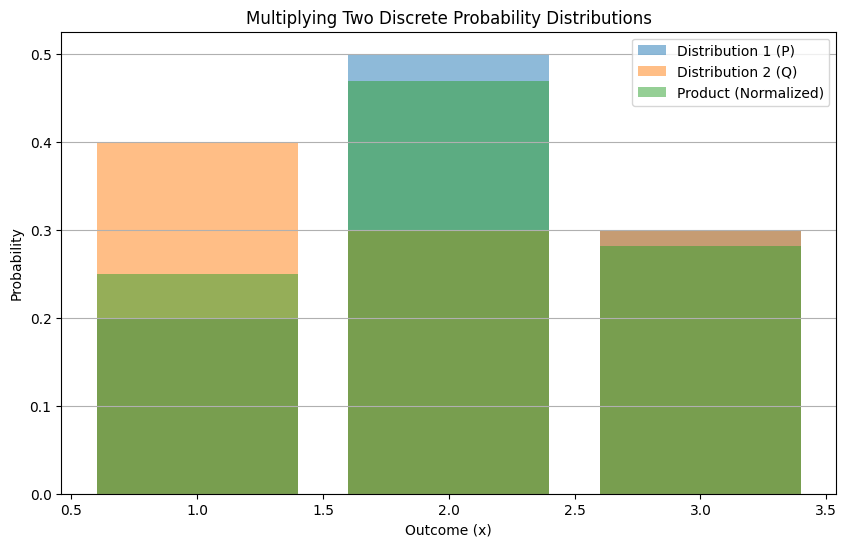

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define the outcomes and probabilities
outcomes = [1, 2, 3]
P = [0.2, 0.5, 0.3]  # Distribution 1
Q = [0.4, 0.3, 0.3]  # Distribution 2

# Multiply the distributions
product = [P[i] * Q[i] for i in range(len(outcomes))]

# Normalize the product
total = sum(product)
normalized_product = [p / total for p in product]

# Plot the distributions
plt.figure(figsize=(10, 6))
plt.bar(outcomes, P, alpha=0.5, label="Distribution 1 (P)")
plt.bar(outcomes, Q, alpha=0.5, label="Distribution 2 (Q)")
plt.bar(outcomes, normalized_product, alpha=0.5, label="Product (Normalized)")
plt.xlabel("Outcome (x)")
plt.ylabel("Probability")
plt.title("Multiplying Two Discrete Probability Distributions")
plt.legend()
plt.grid(axis="y")
plt.show()

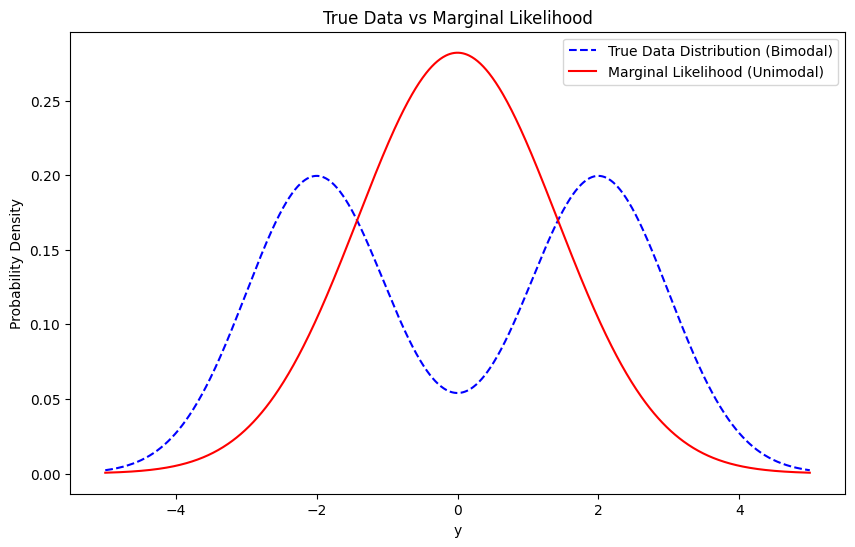

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# True data distribution (bimodal)
y = np.linspace(-5, 5, 1000)
p_y = 0.5 * norm.pdf(y, loc=-2, scale=1) + 0.5 * norm.pdf(y, loc=2, scale=1)

# Marginal likelihood (unimodal Gaussian)
p_marginal = norm.pdf(y, loc=0, scale=np.sqrt(2))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(y, p_y, label="True Data Distribution (Bimodal)", linestyle="--", color="blue")
plt.plot(y, p_marginal, label="Marginal Likelihood (Unimodal)", linestyle="-", color="red")
plt.title("True Data vs Marginal Likelihood")
plt.xlabel("y")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

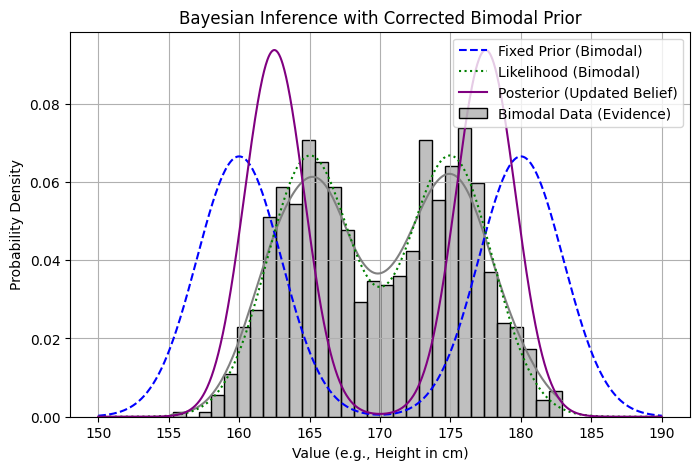

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Set random seed for reproducibility
np.random.seed(42)

# Simulate bimodal data (evidence)
data_bimodal = np.concatenate([np.random.normal(165, 3, 500), np.random.normal(175, 3, 500)])

# Define x range for plotting
x = np.linspace(150, 190, 1000)

# Define a properly bimodal Gaussian Mixture Prior with more separation and lower variance
prior_mixture_fixed = 0.5 * norm.pdf(x, 160, 3) + 0.5 * norm.pdf(x, 180, 3)

# Normalize the prior
prior_mixture_fixed /= np.trapz(prior_mixture_fixed, x)

# Define bimodal likelihood (mixture of Gaussians)
likelihood_bimodal = 0.5 * norm.pdf(x, 165, 3) + 0.5 * norm.pdf(x, 175, 3)

# Compute the posterior using Bayes' Rule: P(theta | D) ∝ P(D | theta) * P(theta)
posterior_fixed = likelihood_bimodal * prior_mixture_fixed

# Normalize the posterior
posterior_fixed /= np.trapz(posterior_fixed, x)

# Plot distributions
plt.figure(figsize=(8, 5))
sns.histplot(data_bimodal, bins=30, kde=True, color="gray", label="Bimodal Data (Evidence)", stat="density", alpha=0.5)
plt.plot(x, prior_mixture_fixed, label="Fixed Prior (Bimodal)", linestyle="dashed", color="blue")
plt.plot(x, likelihood_bimodal, label="Likelihood (Bimodal)", linestyle="dotted", color="green")
plt.plot(x, posterior_fixed, label="Posterior (Updated Belief)", color="purple")

plt.title("Bayesian Inference with Corrected Bimodal Prior")
plt.xlabel("Value (e.g., Height in cm)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid()
plt.show()


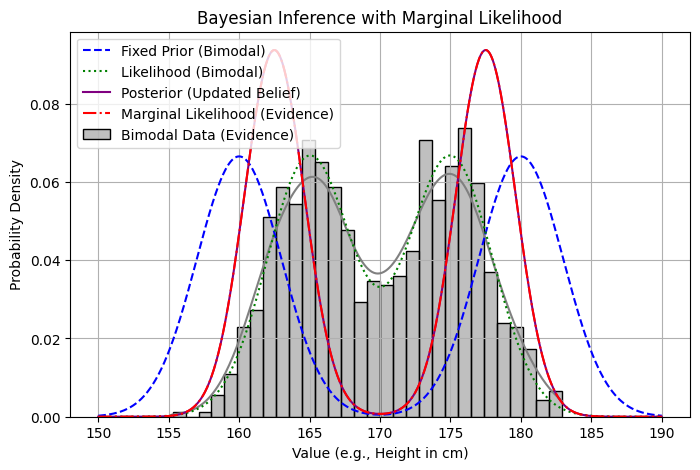

In [21]:
# Compute the marginal likelihood (evidence) by integrating over theta
marginal_likelihood = np.trapz(likelihood_bimodal * prior_mixture_fixed, x)

# Normalize for visualization (not necessary for actual inference, but to scale the curve for plotting)
marginal_likelihood_curve = likelihood_bimodal * prior_mixture_fixed / marginal_likelihood

# Add the marginal likelihood to the plot
plt.figure(figsize=(8, 5))
sns.histplot(data_bimodal, bins=30, kde=True, color="gray", label="Bimodal Data (Evidence)", stat="density", alpha=0.5)
plt.plot(x, prior_mixture_fixed, label="Fixed Prior (Bimodal)", linestyle="dashed", color="blue")
plt.plot(x, likelihood_bimodal, label="Likelihood (Bimodal)", linestyle="dotted", color="green")
plt.plot(x, posterior_fixed, label="Posterior (Updated Belief)", color="purple")
plt.plot(x, marginal_likelihood_curve, label="Marginal Likelihood (Evidence)", linestyle="dashdot", color="red")

plt.title("Bayesian Inference with Marginal Likelihood")
plt.xlabel("Value (e.g., Height in cm)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid()
plt.show()

The **marginal likelihood** (also called **evidence**) in Bayesian statistics is a key quantity for model comparison. Here's a structured breakdown:

### Definition:

- **What it is**: The probability of observing the data D  under a model \( M \), averaged over all possible parameter values \( \theta \) weighted by their prior distribution.
- **Formula**:

$P(D \mid M) = \int P(D \mid \theta, M) \, P(\theta \mid M) \, d\theta$
    - $P(D \mid \theta, M)$ : Likelihood of the data given parameters \theta \.
    - $P(\theta \mid M):$ Prior distribution of \( \theta \).

In [ ]:
The **marginal likelihood** (also called **evidence**) in Bayesian statistics is a key quantity for model comparison. Here's a structured breakdown:

### Definition:

- **What it is**: The probability of \( the data D  under a model \( M \), averaged over all possible parameter values \( \theta \) weighted by their prior distribution.
- **Formula**:

$P(D \mid M) = \int P(D \mid \theta, M) \, P(\theta \mid M) \, d\theta$
    - $P(D \mid \theta, M)$ : Likelihood of the data given parameters \theta \.
    - $P(\theta \mid M):$ Prior distribution of \( \theta \).

### Key Properties:

1. **Model Comparison**:
    - Used to compute **Bayes factors**, which compare two models \( M_1 \) and \( M_2 \):
    \[
    \text{Bayes Factor} = \frac{P(D \mid M_1)}{P(D \mid M_2)}.
    \]
    - A higher marginal likelihood indicates stronger support for a model.
2. **Prior Sensitivity**:
    - Sensitive to the choice of prior. Overly broad or misspecified priors can reduce \( P(D \mid M) \), penalizing complex models unnecessarily.
3. **Occam's Razor**:
    - Automatically penalizes overly complex models by integrating over the entire parameter space. Complex models with large parameter spaces may dilute probability mass, leading to lower marginal likelihoods even if they fit data well.

### Computation Challenges:

- **Analytical Solutions**: Possible only for simple models (e.g., conjugate priors like Normal-Normal, Beta-Binomial).
- **Approximate Methods**:
    - **Laplace Approximation**: Approximates the integrand using a Gaussian around the MAP estimate.
    - **MCMC Methods**: Estimate integrals via sampling (e.g., harmonic mean estimator, but unstable).
    - **Variational Inference**: Uses a tractable distribution to approximate the posterior and compute a lower bound (ELBO).
    - **Nested Sampling**: Directly targets computation of the marginal likelihood.

### Example:

- **Normal Data with Normal Prior**:
    - Data \( D = \{x_1, \dots, x_n\} \), likelihood \( P(D \mid \mu) = \mathcal{N}(\mu, \sigma^2) \), prior \( P(\mu) = \mathcal{N}(\mu_0, \tau^2) \).
    - Marginal likelihood is a Normal distribution:
    \[
    P(D) = \mathcal{N}\left(\mu_0, \sigma^2 + \tau^2\right).
    \]

### Practical Considerations:

- **Use in Model Selection**: Preferred in Bayesian theory but requires careful prior specification.
- **Alternatives**: Cross-validation or information criteria (e.g., WAIC, LOO) are often used when computation is intractable.

### Summary:

The marginal likelihood quantifies how well a model explains the data while accounting for parameter uncertainty. It is foundational for Bayesian model comparison but requires careful computation and prior choices.

\[
\text{Bayes Factor} = \frac{P(D \mid M_1)}{P(D \mid M_2)}.
\]

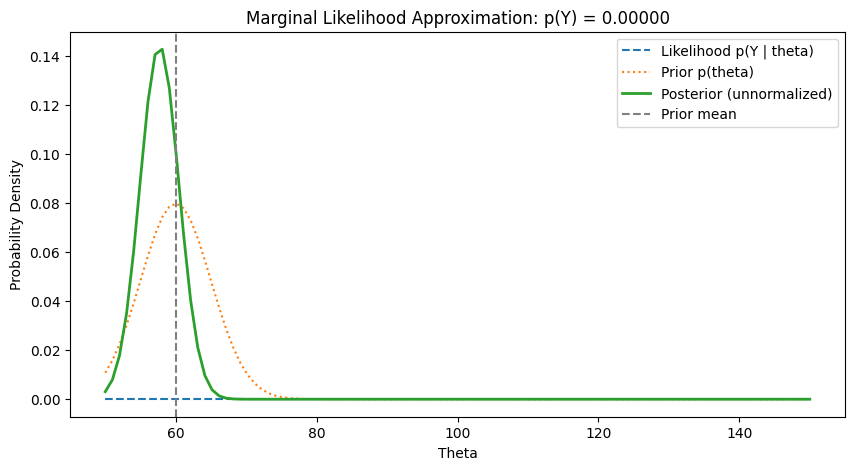

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Observed data
Y = np.array([40, 70, 70, 70, 80, 30, 70, 50, 30])
n = len(Y)

# Likelihood noise variance
sigma2 = 100  # Variance of likelihood model
sigma = np.sqrt(sigma2)

# Prior mean and variance
mu_0 = 60  # Prior mean
sigma2_0 = 25  # Prior variance
sigma_0 = np.sqrt(sigma2_0)

# Discrete theta values for summation approximation
theta_vals = np.linspace(50, 150, 100)  # Considering theta from 50 to 150

# Compute prior probabilities p(theta)
prior_probs = norm.pdf(theta_vals, mu_0, sigma_0)

# Compute likelihood p(Y | theta) for each theta
likelihood_vals = np.array([
    np.prod(norm.pdf(Y, theta, sigma)) for theta in theta_vals
])

# Compute marginal likelihood p(Y) using discrete summation
marginal_likelihood = np.sum(likelihood_vals * prior_probs) * (theta_vals[1] - theta_vals[0])

# Normalize for visualization
posterior_unnorm = likelihood_vals * prior_probs
posterior_unnorm /= np.sum(posterior_unnorm * (theta_vals[1] - theta_vals[0]))

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(theta_vals, likelihood_vals, label="Likelihood p(Y | theta)", linestyle='dashed')
plt.plot(theta_vals, prior_probs, label="Prior p(theta)", linestyle='dotted')
plt.plot(theta_vals, posterior_unnorm, label="Posterior (unnormalized)", linewidth=2)
plt.axvline(mu_0, color='gray', linestyle='--', label="Prior mean")
plt.xlabel("Theta")
plt.ylabel("Probability Density")
plt.title(f"Marginal Likelihood Approximation: p(Y) = {marginal_likelihood:.5f}")
plt.legend()
plt.show()

In [19]:
#Bayesian Linear Regression

Mu Posterior [-0.49168339  2.48893227]


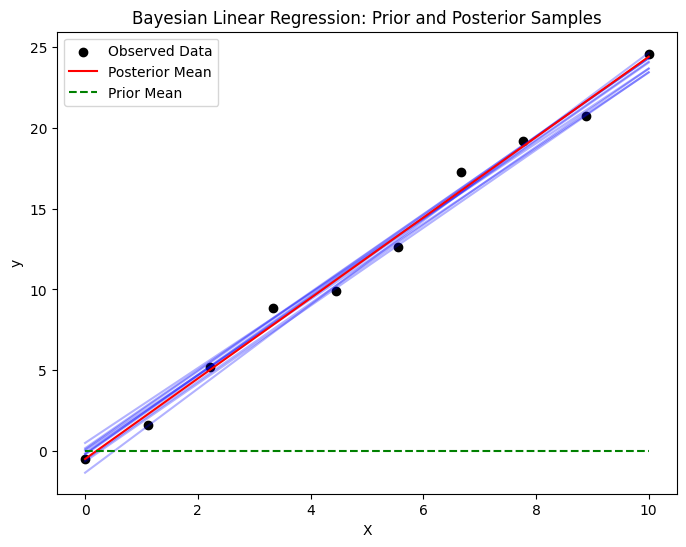

In [22]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 10).reshape(-1, 1)  # Feature
true_slope = 2.5
true_intercept = -1.0
y = true_slope * X.flatten() + true_intercept + np.random.normal(0, 1, X.shape[0])

# Add bias term
X = np.hstack((np.ones((X.shape[0], 1)), X))  # Add intercept term

# Bayesian Prior (Gaussian Prior on Parameters)
mu_prior = np.array([0, 0])  # Prior mean for (intercept, slope)
Sigma_prior = np.array([[10, 0], [0, 10]])  # Prior covariance matrix

# Likelihood: Assume noise variance sigma^2 is known
sigma_likelihood = 1.0  # Standard deviation of noise
sigma2_likelihood = sigma_likelihood ** 2

# Compute Posterior Distribution
Sigma_posterior = np.linalg.inv(np.linalg.inv(Sigma_prior) + (X.T @ X) / sigma2_likelihood)
mu_posterior = Sigma_posterior @ (np.linalg.inv(Sigma_prior) @ mu_prior + (X.T @ y) / sigma2_likelihood)

print('Mu Posterior', mu_posterior)
# Sample from the posterior
samples = np.random.multivariate_normal(mu_posterior, Sigma_posterior, size=100)

# Plot the data and posterior samples
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 1], y, label="Observed Data", color="black")

# Plot sampled regression lines
x_vals = np.linspace(0, 10, 100)
for sample in samples[:10]:  # Plot only a few samples
    plt.plot(x_vals, sample[0] + sample[1] * x_vals, color="blue", alpha=0.3)

# Plot posterior mean regression line
plt.plot(x_vals, mu_posterior[0] + mu_posterior[1] * x_vals, color="red", label="Posterior Mean")

# Plot prior mean regression line
plt.plot(x_vals, mu_prior[0] + mu_prior[1] * x_vals, color="green", linestyle="--", label="Prior Mean")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Bayesian Linear Regression: Prior and Posterior Samples")
plt.show()

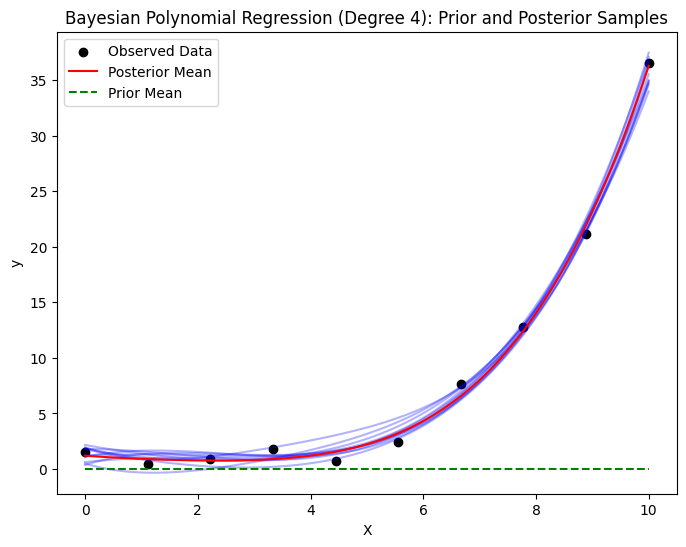

In [23]:
#polynomial input

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# Generate synthetic non-linear data
np.random.seed(42)
X = np.linspace(0, 10, 10).reshape(-1, 1)  # Feature
true_coeffs = [1.0, -3.5, 0.1, -0.02, 0.005]  # True polynomial coefficients for y = 1 - 0.5x + 0.1x^2 - 0.02x^3 + 0.005x^4

y = (
    true_coeffs[0]
    + true_coeffs[1] * X.flatten()
    + true_coeffs[2] * X.flatten()**2
    + true_coeffs[3] * X.flatten()**3
    + true_coeffs[4] * X.flatten()**4
    + np.random.normal(0, 1, X.shape[0])
)

# Transform X to include polynomial features
poly_degree = 4  # Extend to higher-degree polynomials
poly = PolynomialFeatures(degree=poly_degree, include_bias=True)
X_poly = poly.fit_transform(X)  # Create polynomial feature matrix

# Bayesian Prior (Gaussian Prior on Parameters)
mu_prior = np.zeros(X_poly.shape[1])  # Prior mean for coefficients
Sigma_prior = np.eye(X_poly.shape[1]) * 10  # Prior covariance matrix

# Likelihood: Assume noise variance sigma^2 is known
sigma_likelihood = 1.0  # Standard deviation of noise
sigma2_likelihood = sigma_likelihood ** 2

# Compute Posterior Distribution
Sigma_posterior = np.linalg.inv(np.linalg.inv(Sigma_prior) + (X_poly.T @ X_poly) / sigma2_likelihood)
mu_posterior = Sigma_posterior @ (np.linalg.inv(Sigma_prior) @ mu_prior + (X_poly.T @ y) / sigma2_likelihood)

# Sample from the posterior
samples = np.random.multivariate_normal(mu_posterior, Sigma_posterior, size=100)

# Plot the data and posterior samples
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label="Observed Data", color="black")

# Plot sampled regression curves
x_vals = np.linspace(0, 10, 100).reshape(-1, 1)
x_vals_poly = poly.transform(x_vals)
for sample in samples[:10]:  # Plot only a few samples
    plt.plot(x_vals, x_vals_poly @ sample, color="blue", alpha=0.3)

# Plot posterior mean regression curve
plt.plot(x_vals, x_vals_poly @ mu_posterior, color="red", label="Posterior Mean")

# Plot prior mean regression curve
plt.plot(x_vals, x_vals_poly @ mu_prior, color="green", linestyle="--", label="Prior Mean")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Bayesian Polynomial Regression (Degree 4): Prior and Posterior Samples")
plt.show()
